<br> 

***  

# <center>**Notebook 01 – Data Preparation**</center>

<br>

<center>Supporting materials for</center>

### <center>MSc Data Science</center>
## <center>Module: DSM500 Final Project</center>

<br>

<center>5 October 2026</center>

***
<br>

**Purpose of this notebook**  
This notebook reads the raw Home Credit Risk dataset, preprocesses it and saves the output. The input and output files are here:
```
..
    |-- data
        |-- raw
            |-- application_train.csv
        |-- processed
            |-- test.parquet
            |-- train.parquet
            |-- X_test.parquet
            |-- X_train.parquet
            |-- y_test.parquet
            |-- y_train.parquet
```

## Read raw data - full dataset

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Read the full dataset and rename the index to `ID`
path = '..//data//raw//application_train.csv'
index_col = 'SK_ID_CURR'
index_name = 'ID'

df1 = pd.read_csv(path, index_col=index_col)
df1.index.rename('ID', inplace=True)

print(df1.shape)

(307511, 121)


In [2]:
df1.info()

<class 'pandas.DataFrame'>
Index: 307511 entries, 100002 to 456255
Columns: 121 entries, TARGET to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(40), str(16)
memory usage: 325.2 MB


In [3]:
df1.head(5)

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
ID,,,,,,,,,,,,,,,,,,,,,
100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Helper functions to examine a DataFrame (`summarise_column`, `show_summary`)

In [6]:
def show_summary(summary):
    '''
    Tabulate summary details for columns in a dataset.
    '''
    
    print(f'{"Column":30} {"dtype":10}{"N Unique":10}{"N Missing":10}{"Samples":10}')
    print(f'{'-'*100}')
    for col, row in summary.iterrows():
        # Round float samlpe values to save space
        if row.type=='float64':
            samples = [round(s, 2) for s in row.samples[:10]]
        else:
            samples = row.samples[:10]
        print(f'{col:30}{row.type:10}{row.n_vals:10d}{row.n_missing:10d}  {samples}')   
        
def summarise_columns(df, show=False):
    '''
    Summarise the columns in a DataFrame including the name, dtype, number of unique values,
    number of missing values, and some samples.
    '''
    
    summary = pd.DataFrame({
        'column': df.columns,
        'type': df.dtypes.astype(str).values,
        'n_vals': [df[col].nunique(dropna=False) for col in df.columns],   # Include NA in unique count
        'n_missing': df.isna().sum().values
    })
    summary.set_index('column', inplace=True)

    # Create a list of upto 10 samples for each column. Sort the summary by dtype and cardinality.
    samples = [df[col].unique().tolist()[:10] for col in df.columns]
    summary['samples'] = samples
    summary.sort_values(['type', 'n_vals'], inplace=True)

    # Optionally display the summary
    if show:
        show_summary(summary)

    return summary

## Examine the raw data

In [8]:
# Examine the raw data
summary = summarise_columns(df1, show=True)

Column                         dtype     N Unique  N Missing Samples   
----------------------------------------------------------------------------------------------------
AMT_REQ_CREDIT_BUREAU_HOUR    float64            6     41519  [0.0, nan, 1.0, 2.0, 3.0, 4.0]
DEF_60_CNT_SOCIAL_CIRCLE      float64           10      1021  [2.0, 0.0, 1.0, nan, 3.0, 5.0, 4.0, 7.0, 24.0, 6.0]
AMT_REQ_CREDIT_BUREAU_DAY     float64           10     41519  [0.0, nan, 1.0, 3.0, 2.0, 4.0, 5.0, 6.0, 9.0, 8.0]
AMT_REQ_CREDIT_BUREAU_WEEK    float64           10     41519  [0.0, nan, 1.0, 3.0, 2.0, 4.0, 5.0, 6.0, 8.0, 7.0]
DEF_30_CNT_SOCIAL_CIRCLE      float64           11      1021  [2.0, 0.0, 1.0, nan, 3.0, 4.0, 5.0, 6.0, 7.0, 34.0]
AMT_REQ_CREDIT_BUREAU_QRT     float64           12     41519  [0.0, nan, 1.0, 2.0, 4.0, 3.0, 8.0, 5.0, 6.0, 7.0]
CNT_FAM_MEMBERS               float64           18         2  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 9.0, 7.0, 8.0, 10.0]
AMT_REQ_CREDIT_BUREAU_MON     float64           25   

**Observations**  
The data is relatively tidy but requires several transformation:  
* str columns with 2 values - Convert to int. These will be treated as binary.  
* str columns with >2 values - Convert to categorical.  
* int columns with 2 values - Convert to Boolean.  
* int columns with >2 values - Examine the data and sematics and convert to categorical if appropriate.

Missing values:
* categorical columns - replace `nan` with "missing". 
* int and float columns - Do not imupte values in the raw data to avoid leaking data from later test sets into the training set. Instead, add columns to indicate where missing values exist.

## Convert 2-valued objects columns to `int`

In [14]:
# Convert string columns with two values to int (later convert to Boolean)

# Filter on object dtype with 2 values
df2 = df1.copy()
summary = summarise_columns(df1)
convert_to_int = summary[(summary.n_vals==2) & (summary.type=='str')]
print('2-VALUED STRS BEFORE CONVERSION')
show_summary(convert_to_int)
print()

# Convert the remaining string columns to categorical by mapping their values to 0 or 1
df2['FLAG_OWN_CAR'] = df1['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0}).astype(int)
df2['FLAG_OWN_REALTY'] = df1['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0}).astype(int)
df2['NAME_CONTRACT_TYPE'] = df1['NAME_CONTRACT_TYPE'].map(
    {'Cash loans': 1, 'Revolving loans': 0}).astype(int)

# Check the results
print('2-VALUED INTS AFTER CONVERTING OBJECTS')
_ = summarise_columns(df2.loc[:, ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']],
                            show=True)

2-VALUED STRS BEFORE CONVERSION
Column                         dtype     N Unique  N Missing Samples   
----------------------------------------------------------------------------------------------------
NAME_CONTRACT_TYPE            str                2         0  ['Cash loans', 'Revolving loans']
FLAG_OWN_CAR                  str                2         0  ['N', 'Y']
FLAG_OWN_REALTY               str                2         0  ['Y', 'N']

2-VALUED INTS AFTER CONVERTING OBJECTS
Column                         dtype     N Unique  N Missing Samples   
----------------------------------------------------------------------------------------------------
NAME_CONTRACT_TYPE            int64              2         0  [1, 0]
FLAG_OWN_CAR                  int64              2         0  [0, 1]
FLAG_OWN_REALTY               int64              2         0  [1, 0]


## Convert all remaining str columns to categorical

In [16]:
# Get a list of str columns
df3 = df2.copy()
summary = summarise_columns(df2)
str_columns = summary[summary.type=='str'].index
print('STR TYPES BEFORE CONVERTING TO CATEGORICAL')
show_summary(summary.loc[object_columns, :])
print()

df3[str_columns] = df2[str_columns].astype('category')
print('COLUMNS AFTER CONVERTING STR TO CATEGORY')
_ = summarise_columns(df3[str_columns], show=True)

STR TYPES BEFORE CONVERTING TO CATEGORICAL
Column                         dtype     N Unique  N Missing Samples   
----------------------------------------------------------------------------------------------------
CODE_GENDER                   str                3         0  ['M', 'F', 'XNA']
EMERGENCYSTATE_MODE           str                3    145755  ['No', nan, 'Yes']
HOUSETYPE_MODE                str                4    154297  ['block of flats', nan, 'terraced house', 'specific housing']
NAME_EDUCATION_TYPE           str                5         0  ['Secondary / secondary special', 'Higher education', 'Incomplete higher', 'Lower secondary', 'Academic degree']
FONDKAPREMONT_MODE            str                5    210295  ['reg oper account', nan, 'org spec account', 'reg oper spec account', 'not specified']
NAME_FAMILY_STATUS            str                6         0  ['Single / not married', 'Married', 'Civil marriage', 'Widow', 'Separated', 'Unknown']
NAME_HOUSING_TYPE        

## Convert 2-valued int columns to Boolean

In [17]:
# Filter on int with 2 values
df4 = df3.copy()
summary = summarise_columns(df3)
boolean_cols = summary[(summary.type=='int64') & (summary.n_vals==2)].index
print('2-VALUED INTS')
show_summary(summary.loc[boolean_cols, :])
print()

# Convert all columns to Boolean and check the result
df4[boolean_cols] = df3[boolean_cols].astype('boolean')
print('BOOLEANS')
_ = summarise_columns(df4[boolean_cols], show=True)

2-VALUED INTS
Column                         dtype     N Unique  N Missing Samples   
----------------------------------------------------------------------------------------------------
TARGET                        int64              2         0  [1, 0]
NAME_CONTRACT_TYPE            int64              2         0  [1, 0]
FLAG_OWN_CAR                  int64              2         0  [0, 1]
FLAG_OWN_REALTY               int64              2         0  [1, 0]
FLAG_MOBIL                    int64              2         0  [1, 0]
FLAG_EMP_PHONE                int64              2         0  [1, 0]
FLAG_WORK_PHONE               int64              2         0  [0, 1]
FLAG_CONT_MOBILE              int64              2         0  [1, 0]
FLAG_PHONE                    int64              2         0  [1, 0]
FLAG_EMAIL                    int64              2         0  [0, 1]
REG_REGION_NOT_LIVE_REGION    int64              2         0  [0, 1]
REG_REGION_NOT_WORK_REGION    int64              2    

## Convert low cardinality int columns representing codes to categorical

In [19]:
# Filter on int with more than 2 values
df5 = df4.copy()
summary = summarise_columns(df4)
show_summary(summary[(summary.type=='int64')])

# Convert to string then categorical. Update the appropriate columns and check the results
df5['REGION_RATING_CLIENT'] = df4['REGION_RATING_CLIENT'].astype('str').astype('category')
df5['REGION_RATING_CLIENT_W_CITY'] = df4['REGION_RATING_CLIENT_W_CITY'].astype('str').astype('category')

print()
summary = summarise_columns(
    df5[['REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']], 
    show=True)

Column                         dtype     N Unique  N Missing Samples   
----------------------------------------------------------------------------------------------------
REGION_RATING_CLIENT          int64              3         0  [2, 1, 3]
REGION_RATING_CLIENT_W_CITY   int64              3         0  [2, 1, 3]
CNT_CHILDREN                  int64             15         0  [0, 1, 2, 3, 4, 7, 5, 6, 8, 9]
HOUR_APPR_PROCESS_START       int64             24         0  [10, 11, 9, 17, 16, 14, 8, 15, 7, 13]
DAYS_ID_PUBLISH               int64           6168         0  [-2120, -291, -2531, -2437, -3458, -477, -619, -2379, -3514, -3992]
DAYS_EMPLOYED                 int64          12574         0  [-637, -1188, -225, -3039, -3038, -1588, -3130, -449, 365243, -2019]
DAYS_BIRTH                    int64          17460         0  [-9461, -16765, -19046, -19005, -19932, -16941, -13778, -18850, -20099, -14469]

Column                         dtype     N Unique  N Missing Samples   
--------------

## Replace `nan` with missing for categorical columns

In [21]:
# Filter on category columns with missing values
df6 = df5.copy()
summary = summarise_columns(df5)
category_missing_cols = summary[(summary.type=='category') & (summary.n_missing>0)].index
print('BEFORE REPLACING MISSING VALUES')
show_summary(summary.loc[category_missing_cols,:])
print()

# Replace missing values for string features with "missing", and add "missing" to categories
for col in category_missing_cols:
    df6[col] = df5[col].cat.add_categories('missing').fillna('missing')
print('AFTER REPLACING MISSING VALUES')
_ = summarise_columns(df6[category_missing_cols], show=True)

BEFORE REPLACING MISSING VALUES
Column                         dtype     N Unique  N Missing Samples   
----------------------------------------------------------------------------------------------------
EMERGENCYSTATE_MODE           category           3    145755  ['No', nan, 'Yes']
HOUSETYPE_MODE                category           4    154297  ['block of flats', nan, 'terraced house', 'specific housing']
FONDKAPREMONT_MODE            category           5    210295  ['reg oper account', nan, 'org spec account', 'reg oper spec account', 'not specified']
NAME_TYPE_SUITE               category           8      1292  ['Unaccompanied', 'Family', 'Spouse, partner', 'Children', 'Other_A', nan, 'Other_B', 'Group of people']
WALLSMATERIAL_MODE            category           8    156341  ['Stone, brick', 'Block', nan, 'Panel', 'Mixed', 'Wooden', 'Others', 'Monolithic']
OCCUPATION_TYPE               category          19     96391  ['Laborers', 'Core staff', 'Accountants', 'Managers', nan, 'Driver

## Add `was_missing` column to indicate missing numerical data

Consider whether a `was_missing` column will be beneficial as an indicator. Do not create the indicator if a column has relatively few missing values. Only float columns have missing values at this stage.

In [25]:
# Filter on columns which still have missing values. Should only be numerical columns.
# Sort by number of missing values to identify potential correlations between columns
df7 = df6.copy()
summary = summarise_columns(df6).sort_values(['n_missing'])
numerical_missing_cols = summary[(summary.n_missing>0) & (summary.type=='float64')].index

show_summary(summary.loc[numerical_missing_cols, :].sort_values(['n_missing']))
print(f'\nNumber of columns with missing vlaues: {len(numerical_missing_cols):d}')
print(list(numerical_missing_cols), '\n')

# Examine the mode of each column
print(f'{'Column':30} {'Mode':8} {'M Count':8} {'N Unique':8} {'N Missing':15} (%)')
print(f'{'-' * 78}')
sample_size = df6.shape[0]

# Review the values counts (vc), number missing and mode to determine how to deal with `nan`
for col in numerical_missing_cols:
    #summary.loc[col]
    vc = df6[col].value_counts(dropna=False)
    mode = vc.index[0]
    mode_count = vc.iloc[0]
    pct_missing = summary.loc[col].n_missing / sample_size * 100
    print(f'{col:30} {mode:8.2f} {mode_count:8d} {summary.loc[col].n_vals:8d}'\
          f'{summary.loc[col].n_missing:8d} ({pct_missing:5.2f})')
    
print(f'\nNumber of missing numerical columns: {len(numerical_missing_cols)}')

Column                         dtype     N Unique  N Missing Samples   
----------------------------------------------------------------------------------------------------
DAYS_LAST_PHONE_CHANGE        float64         3774         1  [-1134.0, -828.0, -815.0, -617.0, -1106.0, -2536.0, -1562.0, -1070.0, 0.0, -1673.0]
CNT_FAM_MEMBERS               float64           18         2  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 9.0, 7.0, 8.0, 10.0]
AMT_ANNUITY                   float64        13673        12  [24700.5, 35698.5, 6750.0, 29686.5, 21865.5, 27517.5, 41301.0, 42075.0, 33826.5, 20250.0]
AMT_GOODS_PRICE               float64         1003       278  [351000.0, 1129500.0, 135000.0, 297000.0, 513000.0, 454500.0, 1395000.0, 1530000.0, 913500.0, 405000.0]
EXT_SOURCE_2                  float64       119832       660  [0.26, 0.62, 0.56, 0.65, 0.32, 0.35, 0.72, 0.71, 0.21, 0.75]
OBS_30_CNT_SOCIAL_CIRCLE      float64           34      1021  [2.0, 1.0, 0.0, 4.0, 8.0, 10.0, nan, 7.0, 3.0, 6.0]
DEF_60_CNT_S

**Observations**  
Several columns have a relatively low proportion of missing values. To reduce the number of `WAS_MISSING` columns, do not create when the proportion records missing a value is <.5%. Do not create one for the following columns.
```
Column                             Mode  M Count N Unique    N Missing (%)      
--------------------------------------------------------------------------
DAYS_LAST_PHONE_CHANGE             0.00    37672     3774        1 ( 0.00)
CNT_FAM_MEMBERS                    2.00   158357       18        2 ( 0.00)
AMT_ANNUITY                     9000.00     6385    13673       12 ( 0.00)
AMT_GOODS_PRICE               450000.00    26022     1003      278 ( 0.09)
EXT_SOURCE_2                       0.29      721   119832      660 ( 0.21)
OBS_30_CNT_SOCIAL_CIRCLE           0.00   163910       34     1021 ( 0.33)
DEF_60_CNT_SOCIAL_CIRCLE           0.00   280721       10     1021 ( 0.33)
DEF_30_CNT_SOCIAL_CIRCLE           0.00   271324       11     1021 ( 0.33)
OBS_60_CNT_SOCIAL_CIRCLE           0.00   164666       34     1021 ( 0.33)
```
For the remaining columns, many appear correlated. Therefore, create one `WAS_MISSING` column per group of correlated columns.

In [22]:
# Create groups of correlated columns and add a `was_missing` column for each group 
# then calculate based on a majority vote of columns in the group.

# Create dict like: {GROUP_NAME_MISSING: [COL_1, COL2, COL3, ...], ...]
missing_num_groups = {
    'AMT_REQ_CREDIT_BUREAU_MISSING': [
        'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_MON', 
        'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR'],
    'EXT_SOURCE_1_MISSING': ['EXT_SOURCE_1'],
    'EXT_SOURCE_3_MISSING': ['EXT_SOURCE_3'],
    'OWN_CAR_AGE_MISSING': ['OWN_CAR_AGE'],
    'STATS_MISSING': ['TOTALAREA_MODE',
                      'YEARS_BEGINEXPLUATATION_AVG','YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_MODE',
                      'FLOORSMAX_AVG','FLOORSMAX_MEDI', 'FLOORSMAX_MODE', 
                      'LIVINGAREA_AVG','LIVINGAREA_MEDI', 'LIVINGAREA_MODE',
                      'ENTRANCES_AVG','ENTRANCES_MEDI', 'ENTRANCES_MODE',
                      'APARTMENTS_AVG','APARTMENTS_MEDI', 'APARTMENTS_MODE',
                      'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE',
                      'NONLIVINGAREA_AVG','NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE', 
                      'BASEMENTAREA_AVG','BASEMENTAREA_MEDI', 'BASEMENTAREA_MODE',
                      'LANDAREA_AVG','LANDAREA_MEDI', 'LANDAREA_MODE',
                      'YEARS_BUILD_AVG','YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE',
                      'FLOORSMIN_AVG', 'FLOORSMIN_MEDI','FLOORSMIN_MODE',
                      'LIVINGAPARTMENTS_AVG','LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE',
                      'NONLIVINGAPARTMENTS_AVG','NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE',
                      'COMMONAREA_AVG','COMMONAREA_MEDI','COMMONAREA_MODE']
}

# Check that all columns are accounted for
n_missing = 0
for key, value in missing_num_groups.items():
    n_missing += len(value)
    print(key, 'Value count:', len(value))
    print(value)
print(f'\nNumber of columns with missing values: {n_missing}')

AMT_REQ_CREDIT_BUREAU_MISSING Value count: 6
['AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR']
EXT_SOURCE_1_MISSING Value count: 1
['EXT_SOURCE_1']
EXT_SOURCE_3_MISSING Value count: 1
['EXT_SOURCE_3']
OWN_CAR_AGE_MISSING Value count: 1
['OWN_CAR_AGE']
STATS_MISSING Value count: 43
['TOTALAREA_MODE', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_MODE', 'FLOORSMAX_AVG', 'FLOORSMAX_MEDI', 'FLOORSMAX_MODE', 'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'ENTRANCES_AVG', 'ENTRANCES_MEDI', 'ENTRANCES_MODE', 'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'APARTMENTS_MODE', 'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_MODE', 'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE', 'YEARS_BUILD_AVG', 'YEARS_BU

TOTALAREA_MODE               1.00  0.99  0.97  0.96  0.96  0.95  0.90  0.87  0.81  0.80  0.68  0.66  0.66  0.64  0.63
YEARS_BEGINEXPLUATATION_MODE 0.99  1.00  0.97  0.96  0.96  0.95  0.91  0.87  0.82  0.80  0.69  0.67  0.66  0.65  0.64
FLOORSMAX_MODE               0.97  0.97  1.00  0.95  0.98  0.97  0.93  0.89  0.84  0.82  0.70  0.68  0.68  0.66  0.65
LIVINGAREA_MODE              0.96  0.96  0.95  1.00  0.95  0.93  0.90  0.90  0.83  0.82  0.70  0.68  0.68  0.66  0.66
ENTRANCES_MODE               0.96  0.96  0.98  0.95  1.00  0.96  0.93  0.90  0.84  0.83  0.71  0.69  0.68  0.67  0.66
APARTMENTS_MODE              0.95  0.95  0.97  0.93  0.96  1.00  0.92  0.89  0.84  0.82  0.71  0.69  0.68  0.67  0.66
ELEVATORS_MODE               0.90  0.91  0.93  0.90  0.93  0.92  1.00  0.90  0.85  0.83  0.74  0.72  0.71  0.70  0.69
NONLIVINGAREA_MODE           0.87  0.87  0.89  0.90  0.90  0.89  0.90  1.00  0.87  0.85  0.74  0.73  0.73  0.72  0.72
BASEMENTAREA_MODE            0.81  0.82  0.84  0.83  0.8

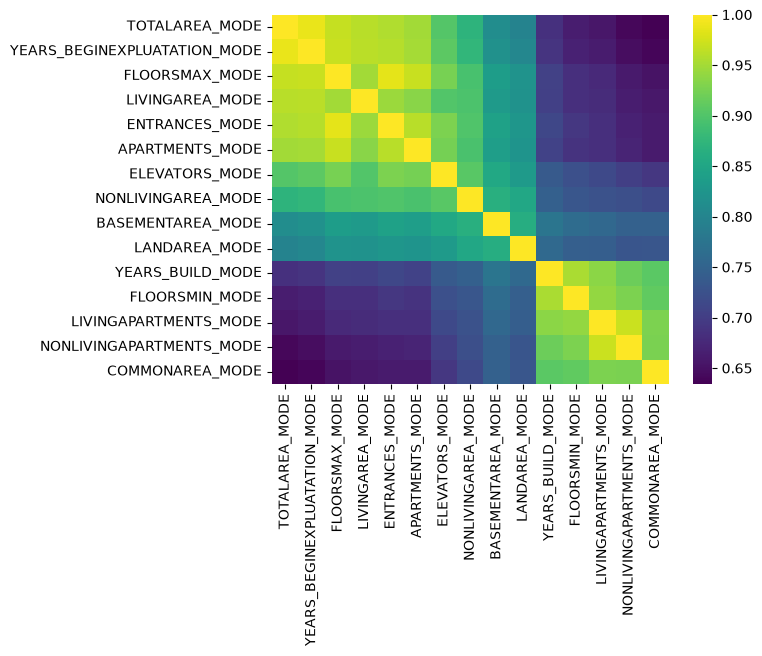

In [23]:
import seaborn as sns

# Check how correlated the groups of triplets are

# Take one feature per triplet - Use MODE because TOTALAREA is missing AVG and MEDI
missing_nums = [col for col in missing_num_groups['STATS_MISSING'] if col.endswith('MODE')]

# Convert NaN and non NaN into int of 1s and 0s
missing_numerical_df = df6[missing_nums].isna()

# Create the correlation matrix
missing_corr = missing_numerical_df.corr()
for row_name, row in missing_corr.iterrows():
    formatted = "  ".join(f"{val:4.2f}" for val in row)
    print(f"{row_name:28} {formatted}")

_ = sns.heatmap(missing_corr, cmap='viridis')

**Observations**  
Correlation is generally high between the features - from 0.99 to 0.63. Although the heatmap indicates that splitting into two groups would increase minimum correlation from 0.63 to 0.8, this is unnecessary to support the imbalance-recovery framework. Instead, we accept the minimum value of 0.63 and retain a single group for simplicity and to minimse the total feature count to avoid increasing CTGAN and XGBoost training times, which was a concern.

In [26]:
# Populate the 'WAS_MISSING' columns based on majority vote of columns missing in the source data
for missing_col, group in missing_num_groups.items():
    majority = len(group) // 2 + 1
    print('Updating column:', missing_col, 'with majority', majority)
    df7[missing_col] = (df6[group].isna().sum(axis=1) >= majority).astype('boolean')

# Check the results
print('\n', df7.loc[:,['AMT_REQ_CREDIT_BUREAU_MISSING']].head(5), '\n')
df6.loc[:, missing_num_groups['AMT_REQ_CREDIT_BUREAU_MISSING']].head(5)

Updating column: AMT_REQ_CREDIT_BUREAU_MISSING with majority 4
Updating column: EXT_SOURCE_1_MISSING with majority 1
Updating column: EXT_SOURCE_3_MISSING with majority 1
Updating column: OWN_CAR_AGE_MISSING with majority 1
Updating column: STATS_MISSING with majority 22

         AMT_REQ_CREDIT_BUREAU_MISSING
ID                                   
100002                          False
100003                          False
100004                          False
100006                           True
100007                          False 



,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_YEAR
ID,,,,,,
100002,0.0,0.0,0.0,0.0,0.0,1.0
100003,0.0,0.0,0.0,0.0,0.0,0.0
100004,0.0,0.0,0.0,0.0,0.0,0.0
100006,NaN,NaN,NaN,NaN,NaN,NaN
100007,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
# Final check of the DataFrame
_ = summarise_columns(df7, show=True)

Column                         dtype     N Unique  N Missing Samples   
----------------------------------------------------------------------------------------------------
TARGET                        boolean            2         0  [True, False]
NAME_CONTRACT_TYPE            boolean            2         0  [True, False]
FLAG_OWN_CAR                  boolean            2         0  [False, True]
FLAG_OWN_REALTY               boolean            2         0  [True, False]
FLAG_MOBIL                    boolean            2         0  [True, False]
FLAG_EMP_PHONE                boolean            2         0  [True, False]
FLAG_WORK_PHONE               boolean            2         0  [False, True]
FLAG_CONT_MOBILE              boolean            2         0  [True, False]
FLAG_PHONE                    boolean            2         0  [True, False]
FLAG_EMAIL                    boolean            2         0  [False, True]
REG_REGION_NOT_LIVE_REGION    boolean            2         0  [Fals

## Create train and test splits and save the data

In [28]:
# Create train and test sets
X_data = df7.drop(columns=['TARGET'])
y_data = df7['TARGET']

print('X_data shape:', X_data.shape)
print('y_data_shape:', y_data.shape)

# Use 10% for the holdout test set
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, 
    test_size = 0.1, 
    stratify=y_data, 
    random_state=42)
y_train = y_train.astype('int64')
y_test = y_test.astype('int64')

# Check the results
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

# Check positive/negative samples
train_index = X_train.index
print('train positive:', len(y_train[y_train==1]))
print('train negative:', len(y_train[y_train==0]))

test_index = X_test.index
print('test positive:', len(y_test[y_test==1]))
print('test negative:', len(y_test[y_test==0]))

X_data shape: (307511, 125)
y_data_shape: (307511,)
X_train: (276759, 125)
y_train: (276759,)
X_test: (30752, 125)
y_test: (30752,)
train positive: 22342
train negative: 254417
test positive: 2483
test negative: 28269


In [20]:
# Save the preprocess data as parquet files
X_train.to_parquet("..\\data\\processed\\X_train.parquet", engine="pyarrow")
y_train.to_frame().to_parquet("..\\data\\processed\\y_train.parquet", engine="pyarrow")

X_test.to_parquet("..\\data\\processed\\X_test.parquet", engine="pyarrow")
y_test.to_frame().to_parquet("..\\data\\processed\\y_test.parquet", engine="pyarrow")

*<center>-- End of notebook --</center>*